## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Importing the Dataset

In [2]:
customer_data = pd.read_csv('D:\Churn_Modelling.csv')

# Droping the ineffective columns
dataset = customer_data.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)
dataset

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Removing the outliers

In [3]:
dataset.drop(dataset[dataset['CreditScore'] <= 359].index, inplace = True)

dataset.drop(dataset[dataset['Age'] >= 71].index, inplace = True)

dataset.drop(dataset[dataset['NumOfProducts'] >= 4].index, inplace = True)

# Shape of Data after removing the outliers
print("Shape of Data after removing outliers: {}".format(dataset.shape))

Shape of Data after removing outliers: (9799, 11)


# Features Engineering

In [4]:
dataset['BalanceSalary'] = dataset.Balance / dataset.EstimatedSalary
dataset['TenureAge'] = dataset.Tenure / (dataset.Age)
dataset['ScoreAge'] = dataset.CreditScore / (dataset.Age)

dataset['tenure_age'] = dataset.Tenure / (dataset.Age - 17)
dataset['tenure_salary'] = dataset.Tenure / (dataset.EstimatedSalary)
dataset['score_age'] = dataset.CreditScore / (dataset.Age - 17)
dataset['score_salary'] = dataset.CreditScore / (dataset.EstimatedSalary)

dataset["newAge"] = dataset["Age"] - dataset["Tenure"]
dataset["newCreditScore"] = pd.qcut(dataset['CreditScore'], 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dataset["AgeScore"] = pd.qcut(dataset['Age'], 8, labels = [1, 2, 3, 4, 5, 6, 7, 8])
dataset["BalanceScore"] = pd.qcut(dataset['Balance'].rank(method = "first"), 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dataset["SalaryScore"] = pd.qcut(dataset['EstimatedSalary'], 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dataset["newEstimatedSalary"] = dataset["EstimatedSalary"] / 12 

dataset['score_balance'] = dataset.Balance / (dataset.CreditScore)
dataset['age_balance'] = dataset.Balance / (dataset.Age)
dataset['balance_salary'] = dataset.Balance / (dataset.EstimatedSalary)
dataset['age_hascrcard'] = dataset.HasCrCard / (dataset.Age)

In [5]:
def product_utilization_rate_by_year(row):
    number_of_products = row.NumOfProducts
    tenure = row.Tenure
    
    if number_of_products == 0:
        return 0
    if tenure == 0:
        return number_of_products
    
    rate = number_of_products / tenure
    return rate

def product_utilization_rate_by_salary(row):
    number_of_products = row.NumOfProducts
    estimated_salary = row.EstimatedSalary
    
    if number_of_products == 0:
        return 0
    
    rate = number_of_products / estimated_salary
    return rate

def countries_monthly_average_salaries(row):
    fr = 3696    
    de = 4740
    sp = 2257
    salary = row.EstimatedSalary / 12
    country = row.Geography
    
    if country == 'Germany':
        return salary / de
    elif country == "France":
        return salary / fr
    elif country == "Spain": 
        return salary / sp

In [6]:
def feature_engineering(cus, is_show_graph = False):
    df_fe = dataset.copy()
    
    # product usage rate by year
    df_fe = df_fe.assign(product_utilization_rate_by_year = df_fe.apply(lambda x: product_utilization_rate_by_year(x), axis = 1))
    
    # product usage rate by estimated salary
    df_fe = df_fe.assign(product_utilization_rate_by_salary = df_fe.apply(lambda x: product_utilization_rate_by_salary(x), axis=1)) 
    
    # average monthly salary according to countries
    df_fe = df_fe.assign(countries_monthly_average_salaries = df_fe.apply(lambda x: countries_monthly_average_salaries(x), axis = 1))
    
    return df_fe

In [7]:
df_fe = feature_engineering(dataset)
df_fe

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,...,BalanceScore,SalaryScore,newEstimatedSalary,score_balance,age_balance,balance_salary,age_hascrcard,product_utilization_rate_by_year,product_utilization_rate_by_salary,countries_monthly_average_salaries
0,619,France,Female,42,2,0.00,1,1,1,101348.88,...,1,6,8445.740000,0.000000,0.000000,0.000000,0.023810,0.500000,0.000010,2.285103
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,...,5,6,9378.548333,137.841875,2044.094146,0.744677,0.000000,1.000000,0.000009,4.155316
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,...,10,6,9494.297500,318.049402,3801.447619,1.401375,0.023810,0.375000,0.000026,2.568803
3,699,France,Female,39,1,0.00,2,0,0,93826.63,...,1,5,7818.885833,0.000000,0.000000,0.000000,0.000000,2.000000,0.000021,2.115499
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,...,8,4,6590.341667,147.659788,2918.856279,1.587055,0.023256,0.500000,0.000013,2.919956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,...,4,5,8022.553333,0.000000,0.000000,0.000000,0.025641,0.400000,0.000021,2.170604
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,...,4,6,8474.980833,111.181415,1639.131714,0.564108,0.028571,0.100000,0.000010,2.293014
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,...,4,3,3507.131667,0.000000,0.000000,0.000000,0.000000,0.142857,0.000024,0.948899
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,...,5,5,7740.710000,97.247811,1787.507381,0.808230,0.023810,0.666667,0.000022,1.633061


In [8]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Converting inputs to numeric values
encoder = LabelEncoder()
df_fe["Geography"] = encoder.fit_transform(df_fe["Geography"])
df_fe["Gender"] = encoder.fit_transform(df_fe["Gender"])

# Encoding categorical data
df_fe = df_fe.drop(['Geography', 'Gender'], axis = 1)
Geography = pd.get_dummies(dataset.Geography, drop_first = True)
Gender = pd.get_dummies(dataset.Gender).iloc[:, 0:]

In [9]:
# Data merging
df_fe = pd.concat([df_fe, Geography, Gender], axis = 1)
df_fe

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalary,...,age_balance,balance_salary,age_hascrcard,product_utilization_rate_by_year,product_utilization_rate_by_salary,countries_monthly_average_salaries,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,...,0.000000,0.000000,0.023810,0.500000,0.000010,2.285103,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744677,...,2044.094146,0.744677,0.000000,1.000000,0.000009,4.155316,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401375,...,3801.447619,1.401375,0.023810,0.375000,0.000026,2.568803,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,...,0.000000,0.000000,0.000000,2.000000,0.000021,2.115499,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587055,...,2918.856279,1.587055,0.023256,0.500000,0.000013,2.919956,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0.000000,...,0.000000,0.000000,0.025641,0.400000,0.000021,2.170604,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0.564108,...,1639.131714,0.564108,0.028571,0.100000,0.000010,2.293014,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0.000000,...,0.000000,0.000000,0.000000,0.142857,0.000024,0.948899,0,0,1,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0.808230,...,1787.507381,0.808230,0.023810,0.666667,0.000022,1.633061,1,0,0,1


### Segregating input and output variables and Scaling data

In [10]:
from sklearn.preprocessing import StandardScaler

# Data inputs
X = df_fe.drop(['Exited'], axis = 1)

# Feature Scaling
sc = StandardScaler()
X = sc.fit_transform(X)
X = pd.DataFrame(X)

# Data outputs
Y = df_fe['Exited']

### Data Devision

In [11]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(7839, 32) (1960, 32) (7839,) (1960,)


# Sampling

In [12]:
from collections import Counter
from imblearn.over_sampling import SMOTEN

sm = SMOTEN()
X_smot_train, Y_smot_train = sm.fit_resample(X_train, y_train)
X_smot_test, Y_smot_test = sm.fit_resample(X_test, y_test)

print('Original dataset shape(Train): ', Counter(y_train))
print('Resampled dataset shape(Train): ', Counter(Y_smot_train))
print('\nOriginal dataset shape(Test): ', Counter(y_test))
print('Resampled dataset shape(Test): ', Counter(Y_smot_test))

Original dataset shape(Train):  Counter({0: 6256, 1: 1583})
Resampled dataset shape(Train):  Counter({0: 6256, 1: 6256})

Original dataset shape(Test):  Counter({0: 1585, 1: 375})
Resampled dataset shape(Test):  Counter({0: 1585, 1: 1585})


# Model Fitting
* GridSearchCV

In [13]:
# Import different models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Scoring functions
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix

# Support functions
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

## Support Vector Machine

### Polynomial kernel

In [47]:
# Defining parameter range
svm_pol_params = {'C': [0.5, 1, 10, 50, 100], 'gamma': [0.1, 0.01, 0.001], 'probability':[True], 'kernel': ['poly'], 'degree': [2, 3]}

cv_svm_pol = GridSearchCV(SVC(), svm_pol_params, verbose = 0, cv = 5)

# Fitting the model for grid search
cv_svm_pol.fit(X_smot_train, Y_smot_train)

# Print best parameter and best score After tuning
print("Best Parameters: ", cv_svm_pol.best_params_)
print("\n Best Score: ", cv_svm_pol.best_score_)
 
# Print classification report
grid_predict_pol = cv_svm_pol.predict(X_smot_test)
print(classification_report(Y_smot_test, grid_predict_pol))

Best Parameters:  {'C': 1, 'degree': 3, 'gamma': 0.1, 'kernel': 'poly', 'probability': True}

 Best Score:  0.8831722316912749
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1585
           1       0.96      0.86      0.91      1585

    accuracy                           0.91      3170
   macro avg       0.91      0.91      0.91      3170
weighted avg       0.91      0.91      0.91      3170



In [48]:
# make predictions on Test data 
test_acc_pol = accuracy_score(Y_smot_test, grid_predict_pol) * 100

print("Accuracy for our testing dataset with tuning is: {:.2f}%".format(test_acc_pol))

Accuracy for our testing dataset with tuning is: 91.01%


### Radial Basis Function kernel

In [16]:
# Fit SVM with RBF kernel
svm_rbf_params = {'C': [0.5, 100, 150], 'gamma': [0.1, 0.01, 0.001], 'probability':[True], 'kernel': ['rbf']}

cv_svm_rbf = GridSearchCV(SVC(), svm_rbf_params, cv = 5, refit = True, verbose = 0)

cv_svm_rbf.fit(X_smot_train, Y_smot_train)

# Print best parameter and best score After tuning
print("Best Parameters: ", cv_svm_rbf.best_params_)
print("\n Best Score: ", cv_svm_rbf.best_score_)
 
# Print classification report
grid_predict_rbf = cv_svm_rbf.predict(X_smot_test)
print(classification_report(Y_smot_test, grid_predict_rbf))

Best Parameters:  {'C': 150, 'gamma': 0.01, 'kernel': 'rbf', 'probability': True}

 Best Score:  0.8853310479862216
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1585
           1       0.95      0.86      0.91      1585

    accuracy                           0.91      3170
   macro avg       0.91      0.91      0.91      3170
weighted avg       0.91      0.91      0.91      3170



In [17]:
# make predictions on Test data
test_acc_rbf = accuracy_score(Y_smot_test, grid_predict_rbf) * 100

print("Accuracy for our testing dataset with tuning is: {:.2f}%".format(test_acc_rbf))

Accuracy for our testing dataset with tuning is: 91.04%


## Logistic Regression

In [18]:
# Fit Primal Logistic Regression
lr_params = {'C': [0.1, 0.5, 1, 10, 50, 100], 'max_iter': [250], 'fit_intercept': [True],
              'intercept_scaling': [1], 'penalty': ['l2'], 'tol': [0.00001, 0.0001, 0.000001]}

cv_lr = GridSearchCV(LogisticRegression(solver = 'lbfgs'), lr_params, cv = 5, refit = True, verbose = 0)

cv_lr.fit(X_smot_train, Y_smot_train)

# Print best parameter and best score After tuning
print("Best Parameters: ", cv_lr.best_params_)
print("\n Best Score: ", cv_lr.best_score_)
 
# Print classification report
grid_predict_lr = cv_lr.predict(X_smot_test)
print(classification_report(Y_smot_test, grid_predict_lr))

E:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
E:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

Best Parameters:  {'C': 0.1, 'fit_intercept': True, 'intercept_scaling': 1, 'max_iter': 250, 'penalty': 'l2', 'tol': 1e-05}

 Best Score:  0.8490457015131003
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1585
           1       0.91      0.85      0.88      1585

    accuracy                           0.88      3170
   macro avg       0.88      0.88      0.88      3170
weighted avg       0.88      0.88      0.88      3170



E:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
# make predictions on Test data 
test_acc_lr = accuracy_score(Y_smot_test, grid_predict_lr) * 100

print("Accuracy for our testing dataset with tuning is: {:.2f}%".format(test_acc_lr))

Accuracy for our testing dataset with tuning is: 88.17%


## Random Forest

In [20]:
rf_params = {'max_depth': [3, 5, 6, 7, 8], 'max_features': ['auto', 'sqrt', 'log2'], 'n_estimators' : [200, 700], 'min_samples_split': [3, 5, 6, 7]}

cv_rf = GridSearchCV(RandomForestClassifier(), rf_params, cv = 5, refit = True, verbose = 0, scoring = 'accuracy')

cv_rf.fit(X_smot_train, Y_smot_train)

# Print best parameter and best score After tuning
print("Best Parameters: ", cv_rf.best_params_)
print("\n Best Score: ", cv_rf.best_score_)
 
# Print classification report
grid_predict_rf = cv_rf.predict(X_smot_test)
print(classification_report(Y_smot_test, grid_predict_rf))

Best Parameters:  {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 6, 'n_estimators': 200}

 Best Score:  0.8699108312231557
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1585
           1       0.97      0.84      0.90      1585

    accuracy                           0.91      3170
   macro avg       0.92      0.91      0.91      3170
weighted avg       0.92      0.91      0.91      3170



In [21]:
# make predictions on Test data 
test_acc_rf = accuracy_score(Y_smot_test, grid_predict_rf) * 100

print("Accuracy for our testing dataset with tuning is: {:.2f}%".format(test_acc_rf))

Accuracy for our testing dataset with tuning is: 90.88%


## K-Nearest Neighbors

In [22]:
k_range = list(range(1, 51))
weight_options = ["uniform", "distance"]

knn_params = dict(n_neighbors = k_range, weights = weight_options)

cv_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv = 5, scoring = 'accuracy', verbose = 1)

cv_knn.fit(X_smot_train, Y_smot_train)

# Print best parameter and best score After tuning
print("Best Parameters: ", cv_knn.best_params_)
print("\n Best Score: ", cv_knn.best_score_)
 
# Print classification report
grid_predict_knn = cv_knn.predict(X_smot_test)
print(classification_report(Y_smot_test, grid_predict_knn))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters:  {'n_neighbors': 29, 'weights': 'distance'}

 Best Score:  0.8746203197250428
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1585
           1       0.92      0.82      0.87      1585

    accuracy                           0.87      3170
   macro avg       0.88      0.87      0.87      3170
weighted avg       0.88      0.87      0.87      3170



In [23]:
# make predictions on Test data 
test_acc_knn = accuracy_score(Y_smot_test, grid_predict_knn) * 100

print("Accuracy for our testing dataset with tuning is: {:.2f}%".format(test_acc_knn))

Accuracy for our testing dataset with tuning is: 87.35%


## Artificial Neural Network

In [27]:
from keras.wrappers.scikit_learn import KerasClassifier

def build_classifier(optimizer):
    classifier = Sequential()
    classifier.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 16, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 16, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 16, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
    classifier.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
    return classifier

classifier = KerasClassifier(build_fn = build_classifier)

parameters = {'batch_size': [16, 32, 64], 'epochs': [100, 250], 'optimizer': ['adam', 'RMSprop', 'sgd']}

# Using Grid Search to test the parameters
grid_search = GridSearchCV(estimator = classifier, param_grid = parameters, scoring = 'accuracy', cv = 5, verbose = 1)

# Fitting the training dataset
grid_search = grid_search.fit(X_smot_train, Y_smot_train)

# Getting the best parameters and the best accuracy
best_parameters = grid_search.best_params_
best_accuracy = grid_search.best_score_

print('Best Parameters: ' , best_parameters)
print('Best Accuracy: ' , best_accuracy)

Fitting 10 folds for each of 18 candidates, totalling 180 fits
Epoch 1/100

If you intended to run this layer in float32, you can safely ignore this warning. If in doubt, this warning is likely only an issue if you are porting a TensorFlow 1.X model to TensorFlow 2.

To change all layers to have dtype float64 by default, call `tf.keras.backend.set_floatx('float64')`. To change just this layer, pass dtype='float64' to the layer constructor. If you are the author of this layer, you can disable autocasting by passing autocast=False to the base Layer constructor.

352/352 [==============================] - 0s 760us/step - loss: 0.4303 - accuracy: 0.8149
Epoch 2/100
352/352 [==============================] - 0s 749us/step - loss: 0.2916 - accuracy: 0.8793
Epoch 3/100
352/352 [==============================] - 0s 758us/step - loss: 0.2722 - accuracy: 0.8855
Epoch 4/100
352/352 [==============================] - 0s 745us/step - loss: 0.2624 - accuracy: 0.8903
Epoch 5/100
352/352 [============

352/352 [==============================] - 0s 720us/step - loss: 0.2018 - accuracy: 0.9176
Epoch 39/100
352/352 [==============================] - 0s 700us/step - loss: 0.2002 - accuracy: 0.9191
Epoch 40/100
352/352 [==============================] - 0s 695us/step - loss: 0.1997 - accuracy: 0.9197
Epoch 41/100
352/352 [==============================] - 0s 691us/step - loss: 0.1996 - accuracy: 0.9188
Epoch 42/100
352/352 [==============================] - 0s 703us/step - loss: 0.1991 - accuracy: 0.9189
Epoch 43/100
352/352 [==============================] - 0s 706us/step - loss: 0.1985 - accuracy: 0.9197
Epoch 44/100
352/352 [==============================] - 0s 702us/step - loss: 0.1982 - accuracy: 0.9206
Epoch 45/100
352/352 [==============================] - 0s 772us/step - loss: 0.1972 - accuracy: 0.9218
Epoch 46/100
352/352 [==============================] - 0s 753us/step - loss: 0.1977 - accuracy: 0.9199
Epoch 47/100
352/352 [==============================] - 0s 718us/step - loss:

Epoch 89/100
352/352 [==============================] - 0s 713us/step - loss: 0.1819 - accuracy: 0.9284
Epoch 90/100
352/352 [==============================] - 0s 704us/step - loss: 0.1824 - accuracy: 0.9274
Epoch 91/100
352/352 [==============================] - 0s 717us/step - loss: 0.1820 - accuracy: 0.9271
Epoch 92/100
352/352 [==============================] - 0s 715us/step - loss: 0.1813 - accuracy: 0.9275
Epoch 93/100
352/352 [==============================] - 0s 720us/step - loss: 0.1818 - accuracy: 0.9277
Epoch 94/100
352/352 [==============================] - 0s 713us/step - loss: 0.1818 - accuracy: 0.9270
Epoch 95/100
352/352 [==============================] - 0s 739us/step - loss: 0.1809 - accuracy: 0.9285
Epoch 96/100
352/352 [==============================] - 0s 784us/step - loss: 0.1815 - accuracy: 0.9278
Epoch 97/100
352/352 [==============================] - 0s 747us/step - loss: 0.1806 - accuracy: 0.9282
Epoch 98/100
352/352 [==============================] - 0s 731us

352/352 [==============================] - 0s 686us/step - loss: 0.1897 - accuracy: 0.9233
Epoch 62/100
352/352 [==============================] - 0s 684us/step - loss: 0.1893 - accuracy: 0.9233
Epoch 63/100
352/352 [==============================] - 0s 683us/step - loss: 0.1890 - accuracy: 0.9245
Epoch 64/100
352/352 [==============================] - 0s 697us/step - loss: 0.1891 - accuracy: 0.9229
Epoch 65/100
352/352 [==============================] - 0s 706us/step - loss: 0.1890 - accuracy: 0.9246
Epoch 66/100
352/352 [==============================] - 0s 719us/step - loss: 0.1885 - accuracy: 0.9227
Epoch 67/100
352/352 [==============================] - 0s 731us/step - loss: 0.1879 - accuracy: 0.9243
Epoch 68/100
352/352 [==============================] - 0s 842us/step - loss: 0.1877 - accuracy: 0.9240
Epoch 69/100
352/352 [==============================] - 0s 829us/step - loss: 0.1877 - accuracy: 0.9240
Epoch 70/100
352/352 [==============================] - 0s 741us/step - loss:

352/352 [==============================] - 0s 1ms/step - loss: 0.2533 - accuracy: 0.8957
Epoch 6/100
352/352 [==============================] - 0s 1ms/step - loss: 0.2469 - accuracy: 0.8981
Epoch 7/100
352/352 [==============================] - 0s 1ms/step - loss: 0.2419 - accuracy: 0.9008
Epoch 8/100
352/352 [==============================] - 0s 1ms/step - loss: 0.2376 - accuracy: 0.9036
Epoch 9/100
352/352 [==============================] - 0s 959us/step - loss: 0.2324 - accuracy: 0.9053
Epoch 10/100
352/352 [==============================] - 0s 951us/step - loss: 0.2292 - accuracy: 0.9062
Epoch 11/100
352/352 [==============================] - 0s 1ms/step - loss: 0.2247 - accuracy: 0.9083
Epoch 12/100
352/352 [==============================] - 0s 993us/step - loss: 0.2207 - accuracy: 0.9088
Epoch 13/100
352/352 [==============================] - 0s 997us/step - loss: 0.2177 - accuracy: 0.9107
Epoch 14/100
352/352 [==============================] - 0s 996us/step - loss: 0.2154 - accu

...

88/88 [==============================] - 0s 952us/step - loss: 0.2323 - accuracy: 0.9056
Epoch 452/500
88/88 [==============================] - 0s 990us/step - loss: 0.2323 - accuracy: 0.9040
Epoch 453/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2325 - accuracy: 0.9049
Epoch 454/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2320 - accuracy: 0.9053
Epoch 455/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2319 - accuracy: 0.9055
Epoch 456/500
88/88 [==============================] - 0s 2ms/step - loss: 0.2319 - accuracy: 0.9054
Epoch 457/500
88/88 [==============================] - 0s 2ms/step - loss: 0.2317 - accuracy: 0.9052
Epoch 458/500
88/88 [==============================] - 0s 2ms/step - loss: 0.2320 - accuracy: 0.9050
Epoch 459/500
88/88 [==============================] - 0s 2ms/step - loss: 0.2319 - accuracy: 0.9056
Epoch 460/500
88/88 [==============================] - 0s 2ms/step - loss: 0.2317 - accuracy: 0.9055:

88/88 [==============================] - 0s 700us/step - loss: 0.6799 - accuracy: 0.5555
Epoch 25/500
88/88 [==============================] - 0s 735us/step - loss: 0.6779 - accuracy: 0.5555
Epoch 26/500
88/88 [==============================] - 0s 718us/step - loss: 0.6753 - accuracy: 0.5555
Epoch 27/500
88/88 [==============================] - 0s 741us/step - loss: 0.6715 - accuracy: 0.5555
Epoch 28/500
88/88 [==============================] - 0s 724us/step - loss: 0.6663 - accuracy: 0.5555
Epoch 29/500
88/88 [==============================] - 0s 706us/step - loss: 0.6585 - accuracy: 0.5562
Epoch 30/500
88/88 [==============================] - 0s 715us/step - loss: 0.6468 - accuracy: 0.6276
Epoch 31/500
88/88 [==============================] - 0s 775us/step - loss: 0.6291 - accuracy: 0.7657
Epoch 32/500
88/88 [==============================] - 0s 718us/step - loss: 0.6033 - accuracy: 0.8026
Epoch 33/500
88/88 [==============================] - 0s 742us/step - loss: 0.5698 - accuracy: 

88/88 [==============================] - 0s 1ms/step - loss: 0.2544 - accuracy: 0.8963
Epoch 185/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2541 - accuracy: 0.8964
Epoch 186/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2542 - accuracy: 0.8965
Epoch 187/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2537 - accuracy: 0.8975: 0s - loss: 0.2541 - accuracy: 0.89
Epoch 188/500
88/88 [==============================] - 0s 872us/step - loss: 0.2537 - accuracy: 0.8972
Epoch 189/500
88/88 [==============================] - 0s 716us/step - loss: 0.2536 - accuracy: 0.8968
Epoch 190/500
88/88 [==============================] - 0s 684us/step - loss: 0.2535 - accuracy: 0.8969
Epoch 191/500
88/88 [==============================] - 0s 706us/step - loss: 0.2533 - accuracy: 0.8968
Epoch 192/500
88/88 [==============================] - 0s 775us/step - loss: 0.2531 - accuracy: 0.8970
Epoch 193/500
88/88 [==============================] - 0s 8

88/88 [==============================] - 0s 1ms/step - loss: 0.2380 - accuracy: 0.9016
Epoch 343/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2378 - accuracy: 0.9033
Epoch 344/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2379 - accuracy: 0.9021
Epoch 345/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2376 - accuracy: 0.9017
Epoch 346/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2376 - accuracy: 0.9021
Epoch 347/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2375 - accuracy: 0.9028
Epoch 348/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2374 - accuracy: 0.9017
Epoch 349/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2372 - accuracy: 0.9017
Epoch 350/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2374 - accuracy: 0.9036
Epoch 351/500
88/88 [==============================] - 0s 1ms/step - loss: 0.2372 - accuracy: 0.9028
Epoc

88/88 [==============================] - 0s 1ms/step - loss: 0.2277 - accuracy: 0.9083
Epoch 1/100

If you intended to run this layer in float32, you can safely ignore this warning. If in doubt, this warning is likely only an issue if you are porting a TensorFlow 1.X model to TensorFlow 2.

To change all layers to have dtype float64 by default, call `tf.keras.backend.set_floatx('float64')`. To change just this layer, pass dtype='float64' to the layer constructor. If you are the author of this layer, you can disable autocasting by passing autocast=False to the base Layer constructor.

391/391 [==============================] - 0s 1ms/step - loss: 0.4368 - accuracy: 0.8266
Epoch 2/100
391/391 [==============================] - 0s 1ms/step - loss: 0.3050 - accuracy: 0.8763
Epoch 3/100
391/391 [==============================] - 0s 1ms/step - loss: 0.2852 - accuracy: 0.8824
Epoch 4/100
391/391 [==============================] - 0s 914us/step - loss: 0.2753 - accuracy: 0.8861
Epoch 5/100
391

In [30]:
# Print classification report
grid_predict_ann = grid_search.predict(X_smot_test)

print(classification_report(Y_smot_test, grid_predict_ann))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1585
           1       0.95      0.86      0.90      1585

    accuracy                           0.91      3170
   macro avg       0.91      0.91      0.91      3170
weighted avg       0.91      0.91      0.91      3170



In [31]:
# make predictions on Test data 
test_acc_ann = accuracy_score(Y_smot_test, grid_predict_ann) * 100

print("Accuracy for our testing dataset with tuning is: {:.2f}%".format(test_acc_ann))

Accuracy for our testing dataset with tuning is: 90.82%


# ROC-AUC

In [49]:
poly_acc = cv_svm_pol.score(X_smot_test, Y_smot_test)
rbf_acc = cv_svm_rbf.score(X_smot_test, Y_smot_test)
lr_acc = cv_lr.score(X_smot_test, Y_smot_test)
rf_acc = cv_rf.score(X_smot_test, Y_smot_test)
knn_acc = cv_knn.score(X_smot_test, Y_smot_test)

In [50]:
auc_svm_poly = roc_auc_score(Y_smot_test, cv_svm_pol.predict_proba(np.array(X_smot_test.values))[:, 1])
auc_svm_rbf = roc_auc_score(Y_smot_test, cv_svm_rbf.predict_proba(np.array(X_smot_test.values))[:, 1])
auc_lr = roc_auc_score(Y_smot_test, cv_lr.predict_proba(np.array(X_smot_test.values))[:, 1])
auc_rf = roc_auc_score(Y_smot_test, cv_rf.predict_proba(np.array(X_smot_test.values))[:, 1])
auc_knn = roc_auc_score(Y_smot_test, cv_knn.predict_proba(np.array(X_smot_test.values))[:, 1])
auc_ann = roc_auc_score(Y_smot_test, grid_predict_ann)

In [51]:
models = ['SVM_POLY', 'SVM_RBF', 'Logistic Regression', 'Random Forest', 'K-Nearest Neighbors']
accuracy = [poly_acc, rbf_acc, lr_acc, rf_acc, knn_acc]
roc_auc = [auc_svm_poly, auc_svm_rbf, auc_lr, auc_rf, auc_knn]

d = {'accuracy': accuracy, 'roc_auc': roc_auc}
df_metrics = pd.DataFrame(d, index = models)
df_metrics

,accuracy,roc_auc
SVM_POLY,0.910095,0.952158
SVM_RBF,0.910410,0.957670
Logistic Regression,0.881703,0.939691
Random Forest,0.908833,0.960638
K-Nearest Neighbors,0.873502,0.940845


In [52]:
fpr_svm_poly, tpr_svm_poly, _ = roc_curve(Y_smot_test, cv_svm_pol.predict_proba(np.array(X_smot_test.values))[:, 1])
fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(Y_smot_test, cv_svm_rbf.predict_proba(np.array(X_smot_test.values))[:, 1])
fpr_lr, tpr_lr, _ = roc_curve(Y_smot_test, cv_lr.predict_proba(np.array(X_smot_test.values))[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(Y_smot_test, cv_rf.predict_proba(np.array(X_smot_test.values))[:, 1])
fpr_knn, tpr_knn, _ = roc_curve(Y_smot_test, cv_knn.predict_proba(np.array(X_smot_test.values))[:, 1])
fpr_ann, tpr_ann, _ = roc_curve(Y_smot_test, grid_predict_ann)

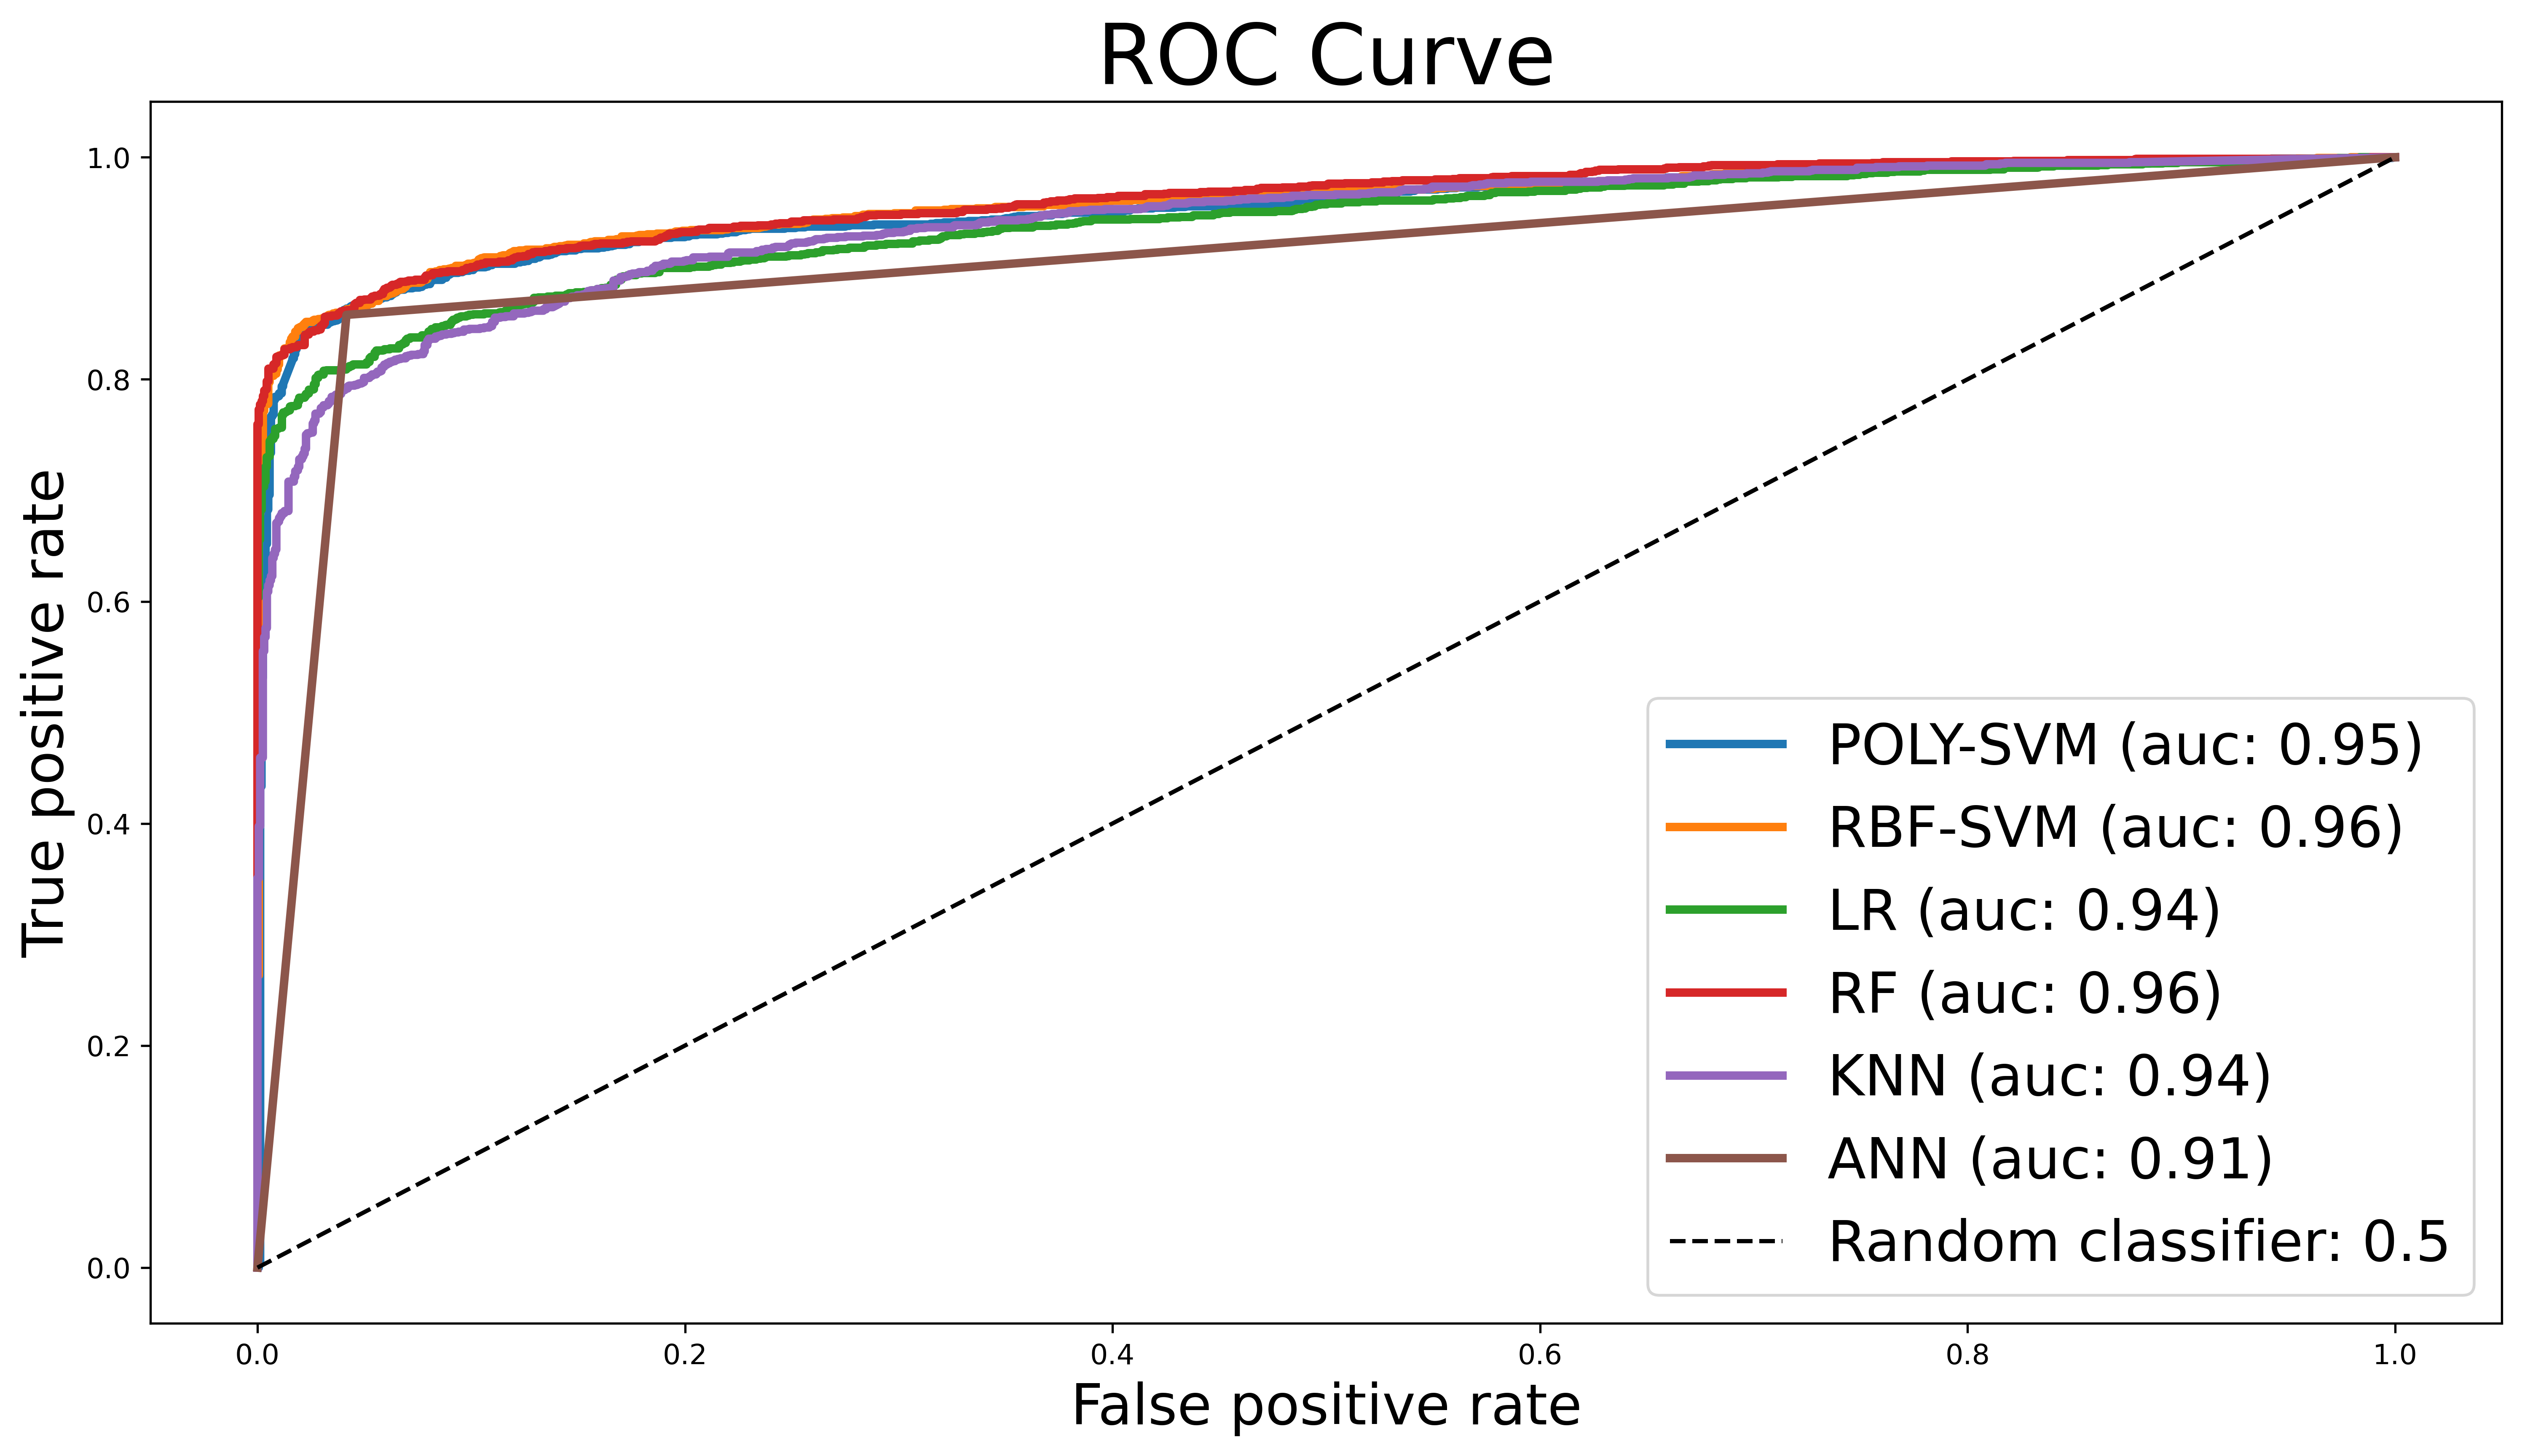

In [53]:
plt.figure(figsize = (15, 8), dpi = 480)
plt.plot(fpr_svm_poly, tpr_svm_poly, label = 'POLY-SVM (auc: {:.2f})'.format(auc_svm_poly), linewidth = 3.0)
plt.plot(fpr_svm_rbf, tpr_svm_rbf, label = 'RBF-SVM (auc: {:.2f})'.format(auc_svm_rbf), linewidth = 3.0)
plt.plot(fpr_lr, tpr_lr, label = 'LR (auc: {:.2f})'.format(auc_lr), linewidth = 3.0)
plt.plot(fpr_rf, tpr_rf, label = 'RF (auc: {:.2f})'.format(auc_rf), linewidth = 3.0)
plt.plot(fpr_knn, tpr_knn, label = 'KNN (auc: {:.2f})'.format(auc_knn), linewidth = 3.0)
plt.plot(fpr_ann, tpr_ann, label = 'ANN (auc: {:.2f})'.format(auc_ann), linewidth = 3.0)

plt.plot([0,1], [0,1], 'k--', label = 'Random classifier: 0.5')
plt.xlabel('False positive rate', fontsize = 20)
plt.ylabel('True positive rate', fontsize = 20)
plt.title('ROC Curve', fontsize = 30)
plt.legend(loc = 'best', fontsize = 20)
plt.savefig('ROC_FE,Sample,CV.png')
plt.show()

# AUC plots

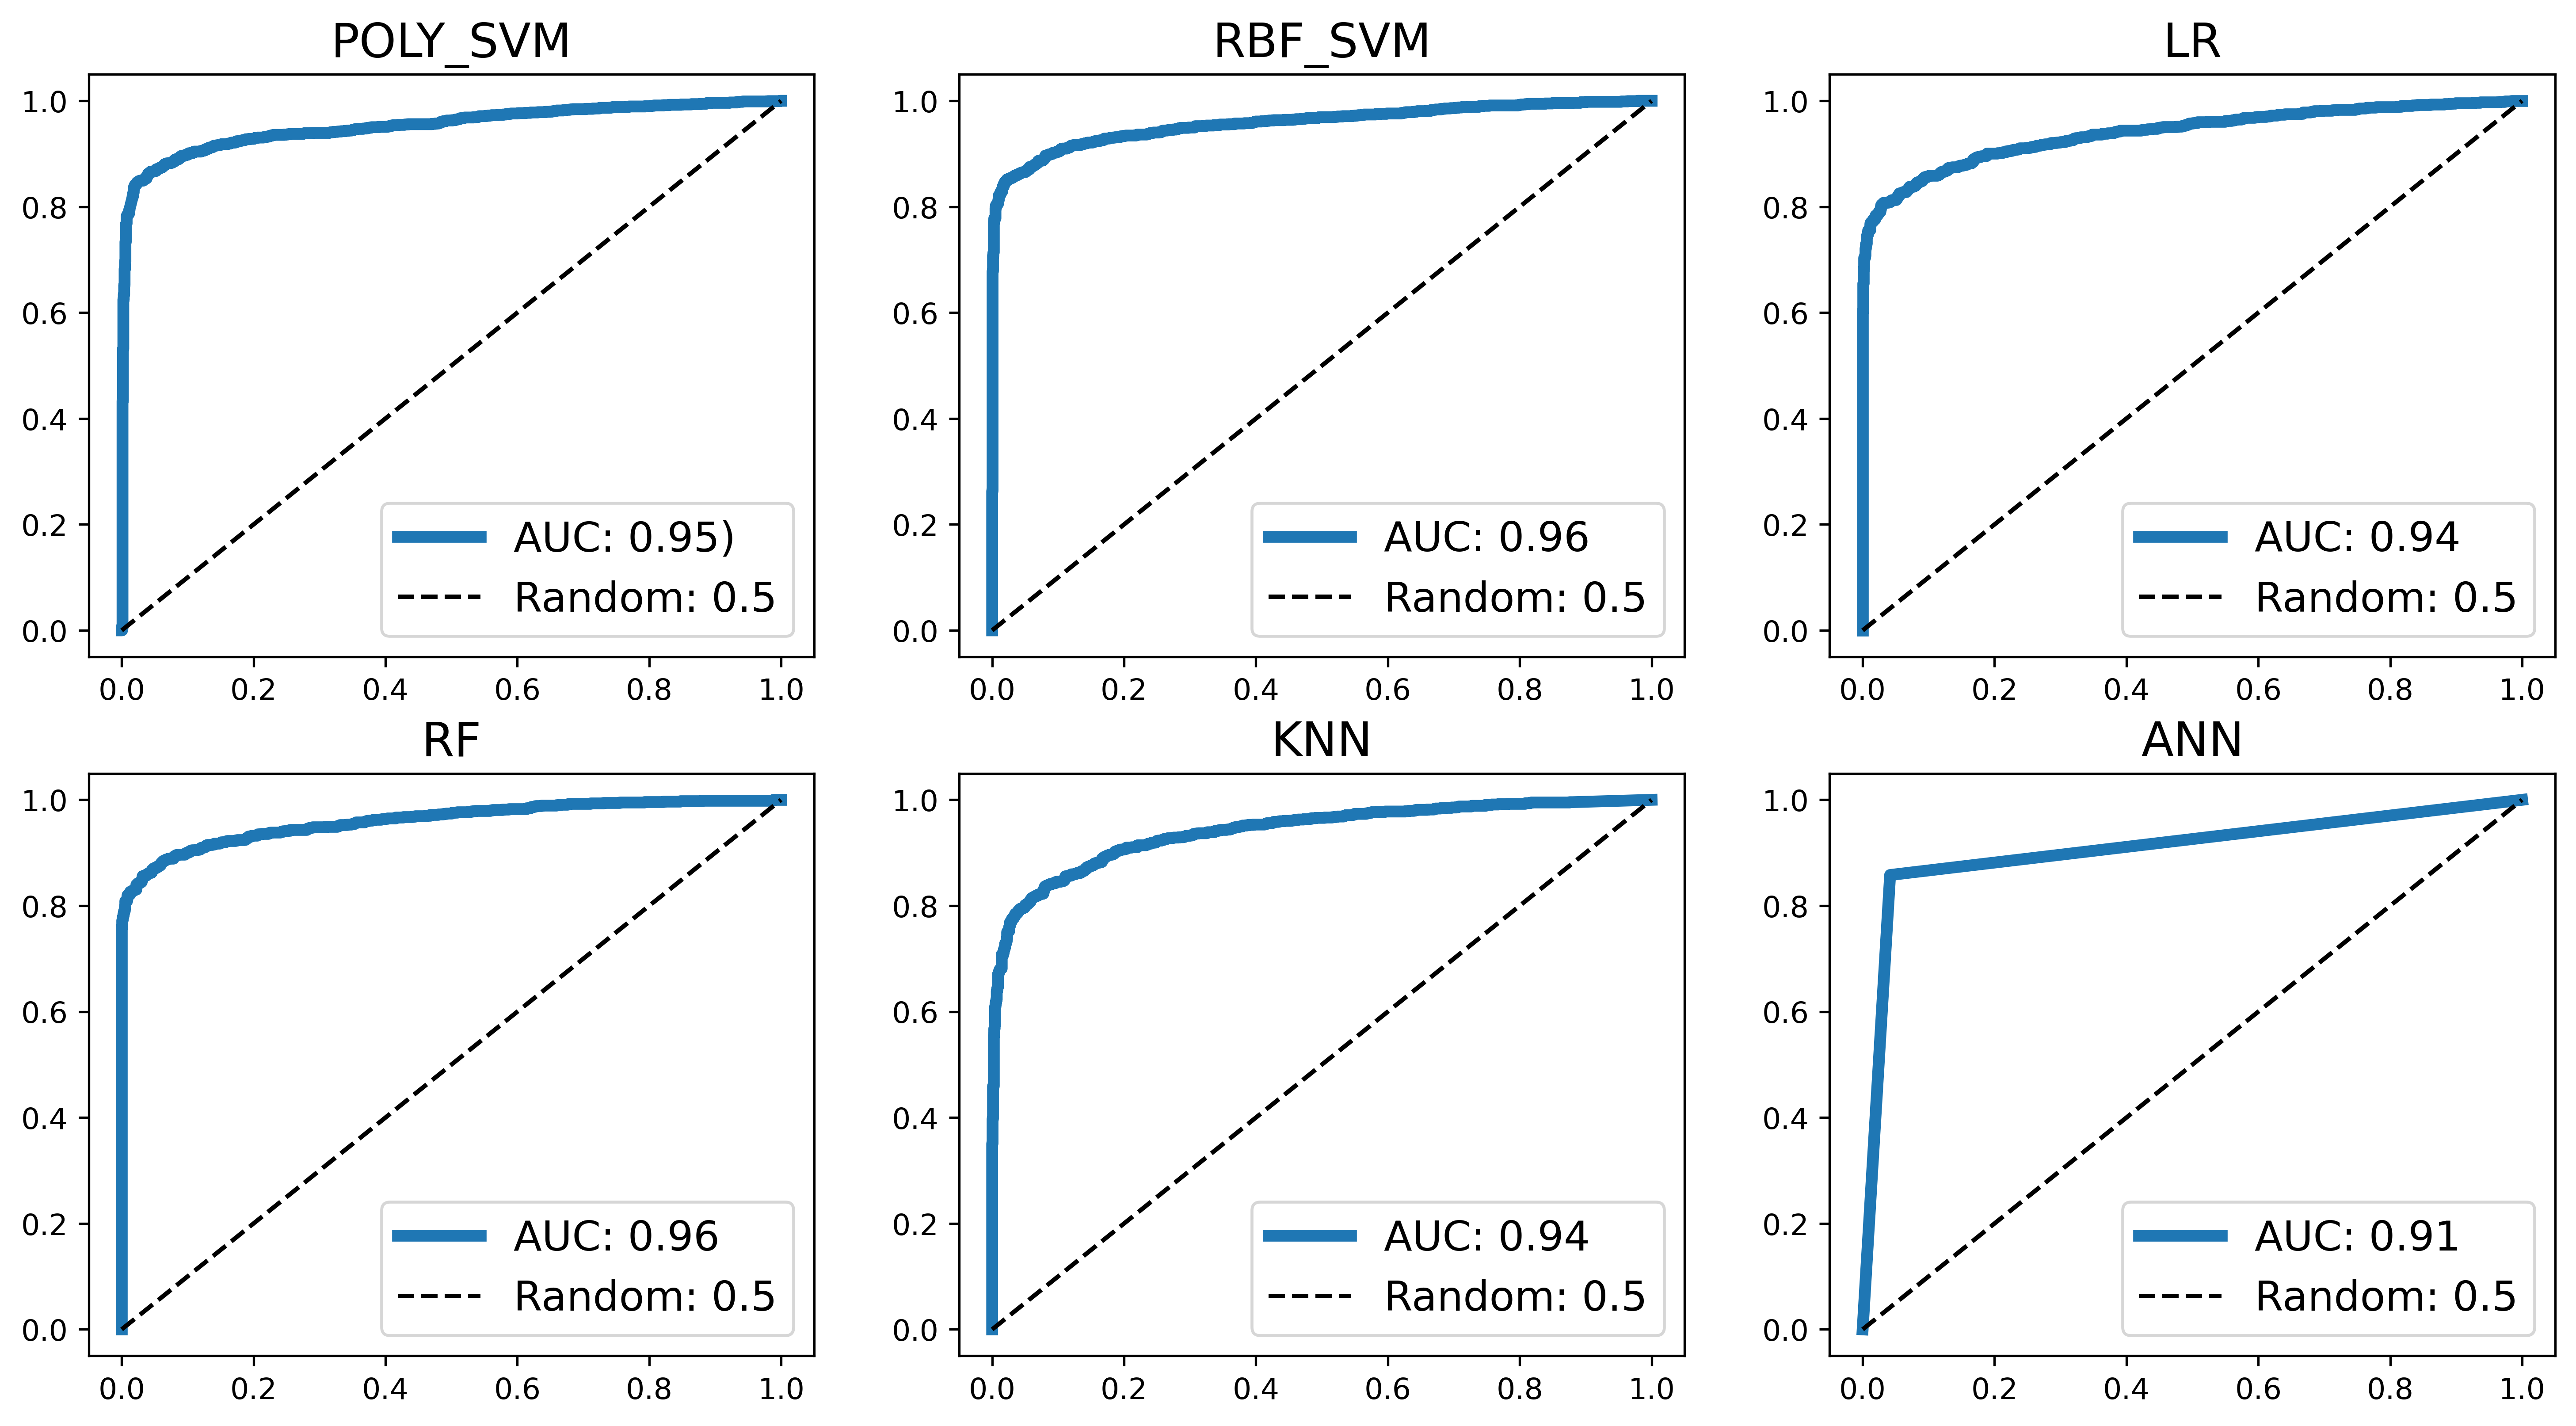

In [54]:
plt.figure(figsize = (15, 8), dpi = 480)

plt.subplot(2, 3, 1)
plt.plot(fpr_svm_poly, tpr_svm_poly, label = 'AUC: {:.2f})'.format(auc_svm_poly), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'best', fontsize = 14)
plt.title('POLY_SVM', fontsize = 16)

plt.subplot(2, 3, 2)
plt.plot(fpr_svm_rbf, tpr_svm_rbf, label = 'AUC: {:.2f}'.format(auc_svm_rbf), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('RBF_SVM', fontsize = 16)

plt.subplot(2, 3, 3)
plt.plot(fpr_lr, tpr_lr, label = 'AUC: {:.2f}'.format(auc_lr), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('LR', fontsize = 16)

plt.subplot(2, 3, 4)
plt.plot(fpr_rf, tpr_rf, label = 'AUC: {:.2f}'.format(auc_rf), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('RF', fontsize = 16)

plt.subplot(2, 3, 5)
plt.plot(fpr_knn, tpr_knn, label = 'AUC: {:.2f}'.format(auc_knn), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('KNN', fontsize = 16)

plt.subplot(2, 3, 6)
plt.plot(fpr_ann, tpr_ann, label = 'AUC: {:.2f}'.format(auc_ann), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('ANN', fontsize = 16)

plt.savefig('AUC_FE,Sample,CV.png')
plt.show()

# Grouped bar chart

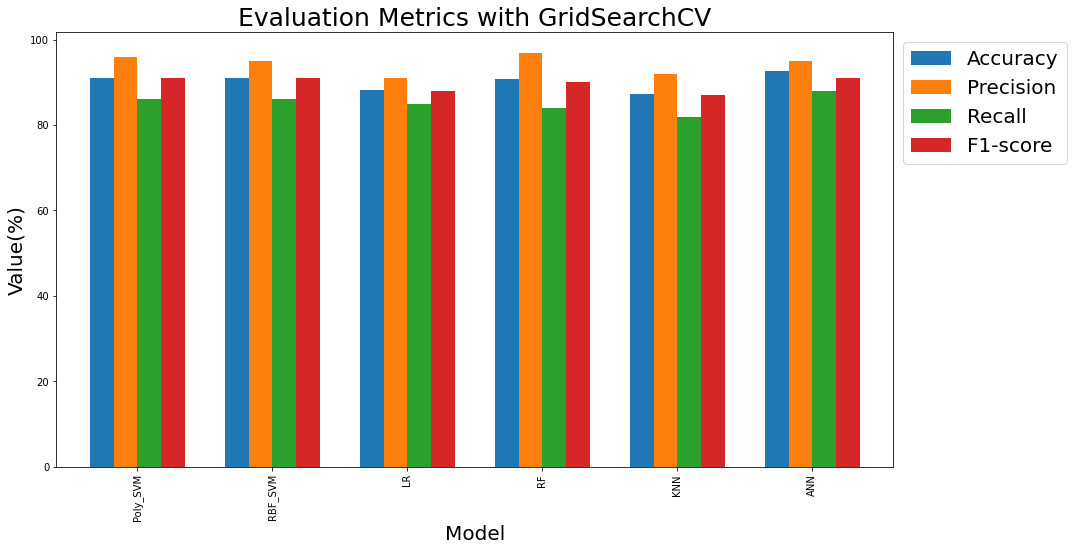

In [1]:
plotdata = pd.DataFrame({"Accuracy":[91.01,91.04,88.17,90.88,87.35,92.62],
                         "Precision":[96,95,91,97,92,95],
                         "Recall":[86,86,85,84,82,88],
                         "F1-score":[91,91,88,90,87,91]},
                        index = ["Poly_SVM", "RBF_SVM", "LR", "RF", "KNN", "ANN"])

plotdata.plot(kind = "bar", figsize = (15, 8), legend = False, width = 0.7)
plt.legend(bbox_to_anchor=(1, 1), loc = 'best', fontsize = 20)
plt.title("Evaluation Metrics with GridSearchCV", fontsize = 25)
plt.xlabel("Model", fontsize = 20)
plt.ylabel("Value(%)", fontsize = 20)
plt.savefig('EvaluationMetrics_CV.png')